# Raw Sensor Readings

Plots the **raw, unprocessed** readings (no filtering, baseline correction, or smoothing)
for a single session — both the **MEMS** channels (VOC, NH3, HCHO, in volts) and the
**SPEC** electrochemical channels (H2S, EtOH, in ppm).

Change `SESSION` to view a different run.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Raw CSV per session. Add more entries here to view other runs.
PATHS = {
    "mix_75_75_1": "../20260517-experiment/75sweat75blood.csv",
    "mix_75_75_2": "../20260518-experiment/75sweat75blood.csv",
    "mix_75_75_3": "../20260522-experiment/75sweat75blood.csv",
    "mix_75_75_4": "../20260523-experiment/75sweat75blood.csv",
    "mix_75_75_5": "../20260525-experiment/75sweat75blood.csv",
    "blood_2":     "../20260421-experiment/1.5_blood.csv",
    "sweat_7":     "../20260429-experiment/sweat_2.csv",
    "blood_5":     "../20260422-experiment/1.5_blood_2.csv",
    "blood_3":     "../20260421-experiment/1.5_blood_2.csv",
    "blood_4":     "../20260422-experiment/1.5_blood.csv",
}

SESSION = "blood_4"

# (column, axis label with units)
CHANNELS = [
    ("voc",      "VOC (V)"),
    ("nh3",      "NH3 (V)"),
    ("hcho",     "HCHO (V)"),
    ("h2s_ppm",  "H2S (ppm)"),
    ("etoh_ppm", "EtOH (ppm)"),
]

In [22]:
def load_raw(path):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_min"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds() / 60.0
    for col, _ in CHANNELS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

raw = load_raw(PATHS[SESSION])
print(f"{SESSION}: {len(raw)} samples, "
      f"{raw['elapsed_min'].iloc[-1]:.1f} min total")
raw[[c for c, _ in CHANNELS]].describe().round(3)

blood_4: 2357 samples, 41.2 min total


,voc,nh3,hcho,h2s_ppm,etoh_ppm
count,2357.000,2357.000,2357.000,2357.000,2357.000
mean,1.813,0.370,0.454,15.182,0.297
std,0.038,0.208,0.206,0.165,7.746
min,1.615,0.102,0.140,14.370,0.000
25%,1.797,0.201,0.272,15.080,0.000
50%,1.811,0.220,0.308,15.180,0.000
75%,1.842,0.583,0.682,15.290,0.000
max,1.863,0.715,0.714,17.140,316.270


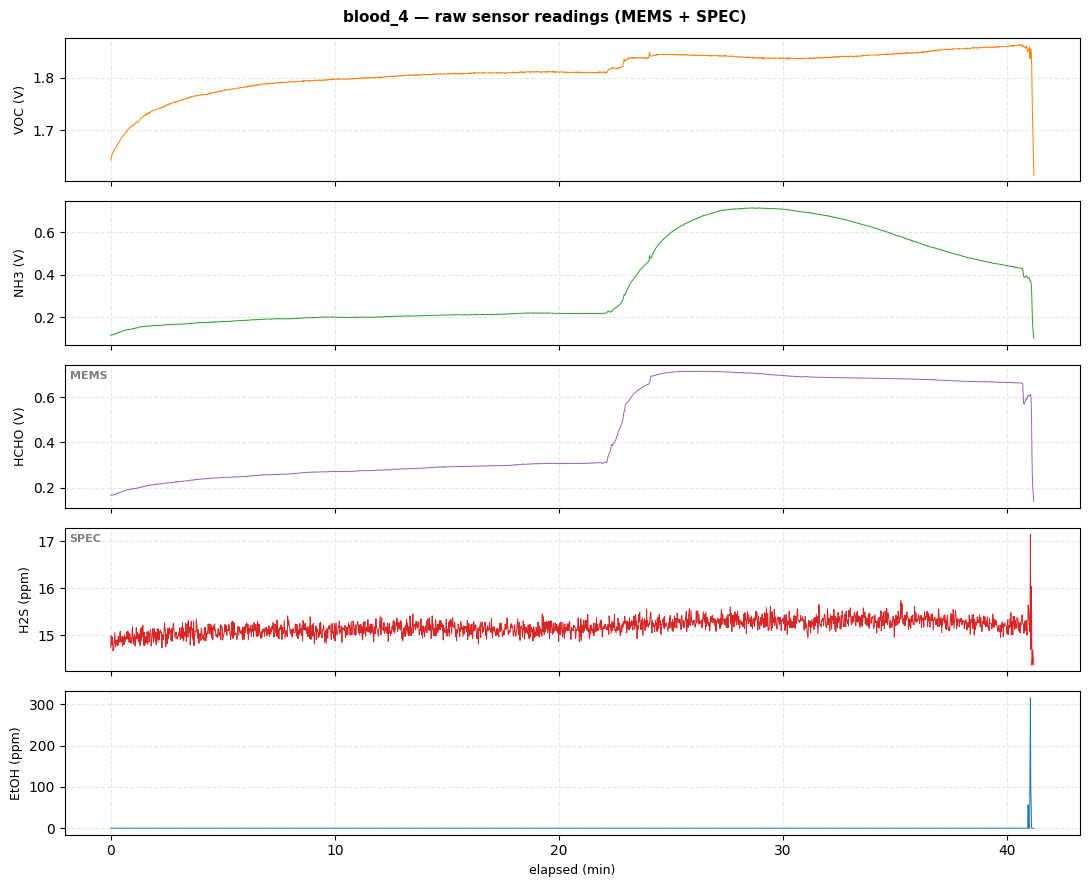

In [23]:
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(11, 9), sharex=True)
fig.suptitle(f"{SESSION} — raw sensor readings (MEMS + SPEC)",
             fontsize=11, fontweight="bold")

COLORS = {"voc":"tab:orange", "nh3":"tab:green", "hcho":"tab:purple",
          "h2s_ppm":"tab:red", "etoh_ppm":"tab:blue"}

for ax, (col, ylabel) in zip(axes, CHANNELS):
    ax.plot(raw["elapsed_min"], raw[col], color=COLORS[col], linewidth=0.7)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle="--")

# visual divider between MEMS (top 3) and SPEC (bottom 2)
axes[2].annotate("MEMS", xy=(0.005, 0.9), xycoords="axes fraction",
                 fontsize=8, color="grey", fontweight="bold")
axes[3].annotate("SPEC", xy=(0.005, 0.9), xycoords="axes fraction",
                 fontsize=8, color="grey", fontweight="bold")

axes[-1].set_xlabel("elapsed (min)", fontsize=9)
plt.tight_layout()
plt.show()